In [280]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

In [281]:
# ---------------- CONFIGURATION ----------------
ship_path = "Pair-5/ship-result.png"
debris_path = "Pair-5/debris-result.png"
threshold = 200   # pixel threshold for verdict
mode = 'A'        # 'A' for transparent, 'B' for shifted overlay
# ------------------------------------------------

In [282]:


def detect_red_boxes(img):
    """Detect red bounding boxes while ignoring text labels."""
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # detect red color
    lower_red1, upper_red1 = (0, 100, 100), (10, 255, 255)
    lower_red2, upper_red2 = (160, 100, 100), (180, 255, 255)
    mask = cv2.inRange(hsv, lower_red1, upper_red1) + cv2.inRange(hsv, lower_red2, upper_red2)

    # Morphological closing to remove text gaps
    kernel = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=3)

    # Find contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = []

    for c in contours:
        x, y, w, h = cv2.boundingRect(c)

        # Ignore tiny or very wide regions (like text labels)
        aspect_ratio = w / float(h)
        area = w * h
        if area < 200:     # too small (noise or text)
            continue
        if aspect_ratio > 3.5:  # too wide (text line)
            continue
        boxes.append((x, y, x + w, y + h))

    return boxes




In [283]:
def get_centers(boxes):
    centers = []
    for (x1, y1, x2, y2) in boxes:
        centers.append(((x1 + x2)//2, (y1 + y2)//2))
    return centers


In [284]:
def compute_distances(centers1, centers2):
    distances = []
    for i, c1 in enumerate(centers1):
        for j, c2 in enumerate(centers2):
            dist = math.sqrt((c1[0]-c2[0])**2 + (c1[1]-c2[1])**2)
            distances.append(((i, j), dist))
    return distances

In [285]:
# Load images
ship_img = cv2.imread(ship_path)
debris_img = cv2.imread(debris_path)

In [286]:
h, w, _ = ship_img.shape
debris_img_resized= cv2.resize(debris_img, (w, h))

In [287]:
# Detect boxes and centers
ship_boxes = detect_red_boxes(ship_img)
debris_boxes = detect_red_boxes(debris_img_resized)

ship_centers = get_centers(ship_boxes)
debris_centers = get_centers(debris_boxes)

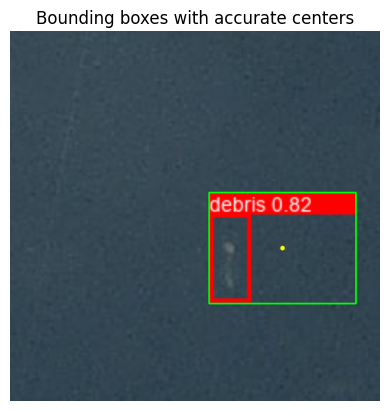

In [288]:
debug = img.copy()
for (x1, y1, x2, y2) in boxes:
    c = ((x1 + x2)//2, (y1 + y2)//2)
    cv2.rectangle(debug, (x1,y1), (x2,y2), (0,255,0), 2)
    cv2.circle(debug, c, 4, (0,255,255), -1)
plt.imshow(cv2.cvtColor(debug, cv2.COLOR_BGR2RGB))
plt.title("Bounding boxes with accurate centers")
plt.axis("off")
plt.show()


In [289]:
print(f"Detected {len(ship_boxes)} ship boxes and {len(debris_boxes)} debris boxes.")


Detected 2 ship boxes and 1 debris boxes.


In [290]:

# Compute distances between each ship and debris
distances = compute_distances(ship_centers, debris_centers)
for pair, dist in distances:
    print(f"Ship {pair[0]} ↔ Debris {pair[1]} = {dist:.2f} px")

Ship 0 ↔ Debris 0 = 80.00 px
Ship 1 ↔ Debris 0 = 305.79 px


In [291]:

if distances:
    closest_pair, min_dist = min(distances, key=lambda x: x[1])
    print(f"\nClosest pair: Ship {closest_pair[0]} ↔ Debris {closest_pair[1]} = {min_dist:.2f}px")
    verdict = "⚠️ Possible culprit" if min_dist < threshold else "✅ No link detected"
    print("Verdict:", verdict)
else:
    print("No bounding boxes detected.")


Closest pair: Ship 0 ↔ Debris 0 = 80.00px
Verdict: ⚠️ Possible culprit


In [292]:

if mode == 'A':
    # Transparent blend
    combined = cv2.addWeighted(ship_img, 0.6, debris_img_resized, 0.6, 0)
else:
    # Shifted overlay
    shift_x, shift_y = 100, 60
    shifted = np.zeros_like(ship_img)
    y1, y2 = shift_y, min(shift_y + h, shifted.shape[0])
    x1, x2 = shift_x, min(shift_x + w, shifted.shape[1])
    shifted[y1:y2, x1:x2] = debris_img_resized[0:y2-y1, 0:x2-x1]
    combined = cv2.addWeighted(ship_img, 0.6, shifted, 0.6, 0)

In [293]:
# Draw connections and distance labels
for (i, j), dist in distances:
    c1 = ship_centers[i]
    c2 = debris_centers[j]
    cv2.line(combined, c1, c2, (0, 255, 0), 2)
    mid = ((c1[0]+c2[0])//2, (c1[1]+c2[1])//2)
    cv2.putText(combined, f"{dist:.1f}", mid, cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)

In [294]:
# Draw centers
for c in ship_centers:
    cv2.circle(combined, c, 4, (255,0,0), -1)
for c in debris_centers:
    cv2.circle(combined, c, 4, (0,255,255), -1)


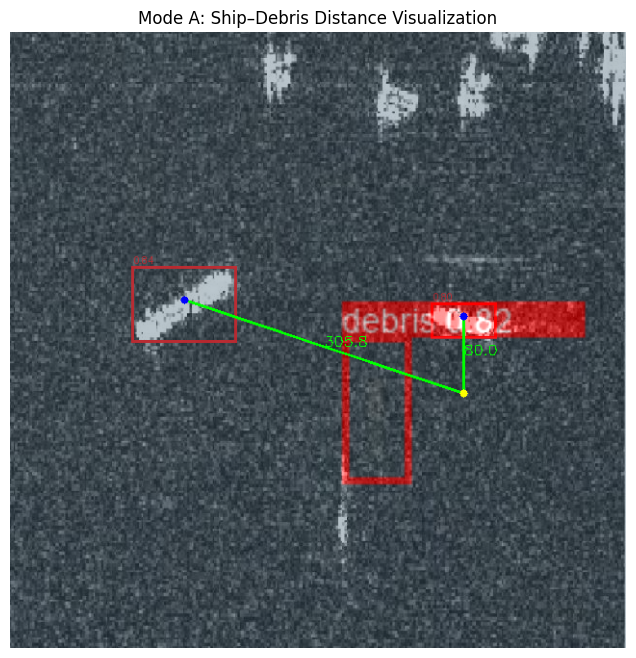

In [295]:
plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(combined, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f"Mode {mode}: Ship–Debris Distance Visualization")
plt.show()